# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

$$P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b$$

где $\sigma(z)$ — сигмоида:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

$$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$


### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [62]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


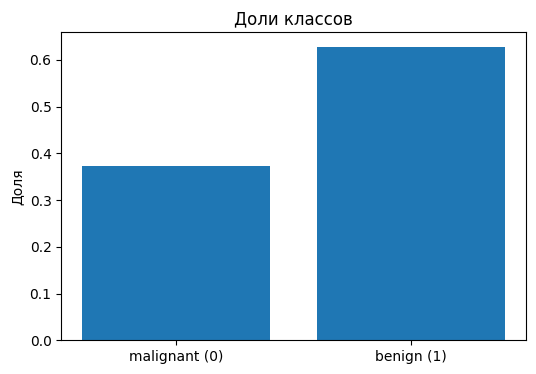

In [63]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [64]:
# YOUR CODE HERE
# 1) Разбейте данные на train/test
# 2) Создайте scaler
# 3) Обучите scaler на train
# 4) Преобразуйте X_train и X_test

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [65]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [66]:
def compute_log_loss(y_true, y_pred_proba):
    y_pred_proba_sc = np.clip(y_pred_proba,1e-15,1 - 1e-15)
    loss = -np.mean(y_true*(np.log(y_pred_proba_sc)) + (1 - y_true)*(np.log(1 - y_pred_proba_sc)))
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
* $z = Xw + b$
* $\hat{p} = \sigma(z)$

Градиенты для log-loss: $dw = \frac{1}{n} X^T(\hat{p} - y), \qquad db = \frac{1}{n}\sum(\hat{p} - y)$


Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [67]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    # 1) посчитать z
    # 2) посчитать p = sigmoid(z)
    # 3) посчитать loss
    # 4) посчитать dw и db
    z = X @ w + b
    p = sigmoid(z)
    loss = compute_log_loss(y,p)
    
    n = X.shape[0]
    dw = (X.T @ (p - y)) / n
    db = np.mean((p - y))
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [68]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        # 2) в цикле вызовите forward_backward
        # 3) обновите параметры
        # 4) сохраните loss в self.loss_history
        n_features = X.shape[1]
        # стартовые параметры
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        for _ in range(self.n_iters):
            p,loss,dw,db = forward_backward(X,y,self.w,self.b)
            self.w = self.w - self.learning_rate*dw
            self.b = self.b - self.learning_rate*db
            
            #сеттим значение в массив
            self.loss_history.append(loss)
        
        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

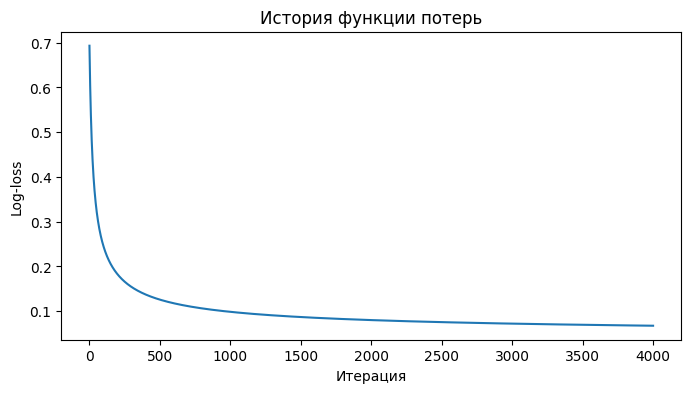

Accuracy метрика: 0.9736842105263158


In [69]:
my_model = MyLogisticRegressionGD(
    learning_rate=0.01,   # подберите разумное значение
    n_iters=4000,         # задайте число итераций
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled,y_train).predict(X_test_scaled)

my_pred_test = my_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test,my_pred_test)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

print(f"Accuracy метрика: {test_acc}")

#### Выводы по блоку
1) по графику видно что loss уменьшается с количеством итераций
2) на текущем стейдже тест оценил через accuracy, на выходе получилось 0.97, что довольно не плохо

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [70]:
# YOUR CODE HERE
my_proba_test = my_model.predict_proba(X_test_scaled)
my_pred_test = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test,my_pred_test),
    "precision": precision_score(y_test,my_pred_test),
    "recall": recall_score(y_test,my_pred_test),
    "f1": f1_score(y_test,my_pred_test),
    "roc_auc": roc_auc_score(y_test,my_proba_test),
}

pd.Series(my_metrics).round(4)

accuracy     0.9737
precision    0.9859
recall       0.9722
f1           0.9790
roc_auc      0.9957
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

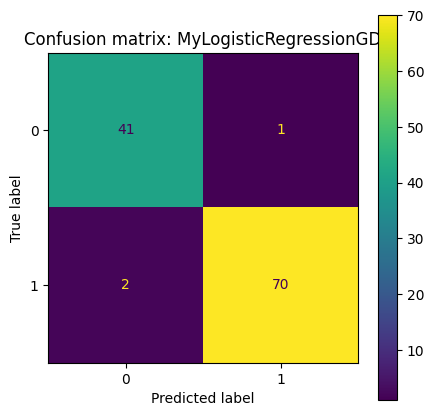

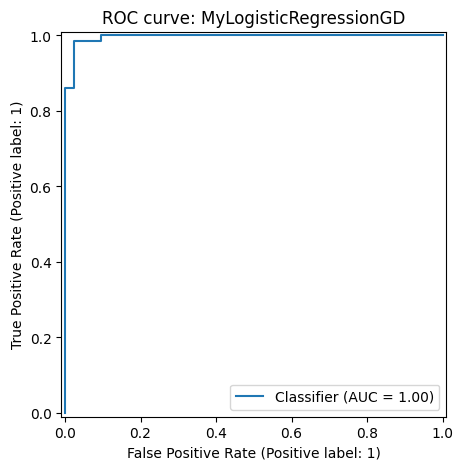

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [98]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [72]:
sk_model = LogisticRegression(max_iter=1000)

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите вероятности и классы на test
# 3) посчитайте те же метрики
sk_model.fit(X_train_scaled,y_train)

sk_proba_test = sk_model.predict_proba(X_test_scaled)[:,1]
sk_pred_test = sk_model.predict(X_test_scaled)

sk_metrics = {
    "accuracy": accuracy_score(y_test,sk_pred_test),
    "precision": precision_score(y_test,sk_pred_test),
    "recall": recall_score(y_test,sk_pred_test),
    "f1": f1_score(y_test,sk_pred_test),
    "roc_auc": roc_auc_score(y_test,sk_proba_test),
}

pd.Series(sk_metrics).round(4)

accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [73]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9737,0.9859,0.9722,0.9790,0.9957
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,-0.050812,0.648342,0.699153
21,worst texture,-0.733522,-1.255088,0.521566
10,radius error,-0.566444,-1.082965,0.516521
28,worst symmetry,-0.499303,-0.939181,0.439879
13,area error,-0.516538,-0.929104,0.412566
26,worst concavity,-0.429202,-0.823151,0.393948
15,compactness error,0.297225,0.647227,0.350002
27,worst concave points,-0.636987,-0.953686,0.316699
23,worst area,-0.648136,-0.947756,0.299620
17,concave points error,-0.147345,-0.443784,0.296440


#### Вывод по блоку
1) результаты различны, тк под капотом сайкета юзается регуляризатор и разные learning_rate, потому значения могли разойтись
2) в библиотечной реализации используется другой оптимизатор(более стабильный), есть регуляризация по умолчанию и ставиться сразу подходящий рейт, все это в сумме может давать более устойчивую реализацию 

## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [74]:
thresholds = [0.3, 0.5, 0.7]
rows = []

my_proba_test = my_model.predict_proba(X_test_scaled)

for threshold in thresholds:
    pred_thr = (my_proba_test >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test,pred_thr),
        "precision": precision_score(y_test,pred_thr),
        "recall": recall_score(y_test,pred_thr),
        "f1": f1_score(y_test,pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9561,0.9467,0.9861,0.9660
1,0.5,0.9737,0.9859,0.9722,0.9790
2,0.7,0.9211,0.9846,0.8889,0.9343


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему для логистической регрессии используется сигмоида?
2. Почему в этой задаче мы считаем **log-loss**, а не MSE?
3. Зачем стандартизировать признаки перед обучением градиентным спуском?
4. Насколько близки метрики вашей реализации к `scikit-learn`?
5. Почему библиотечная модель обычно работает стабильнее и быстрее?
6. Как изменение порога влияет на precision и recall?
7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?

## Финальные ответы
1) Сигмоида помогает сжать логит находящийся на скоупе [-бесконечность, +бесконечность] в диапазон [0, 1] и уже на их основе давать класс
2) тк после likelihood значение довольно маленькое то мы его логарифмируем, а отличие в том, что logloss более естественен для бинарной классификации тк работает с вероятностями и дает штраф за неправильные ответы, MSE для логистической менее удачен как минимум потому, что хуже работает с вероятностью интерпретации
3) для градиентного спуска обязательно приводить их к общему масштабу, чтобы и веса были в одном масштабе,и производная хорошо считалась
4) метрики почти схожи отличия наблюдатся ток в сотых частях
5) как и говорил ранее, все благодаря более лучшему оптимизатору, регуляризации и сверху рейт выставляется нужный там сам
6) при изменении порога меняется классификация объектов на прямую, что и выражается на recall с precision на прямую
7) логистическая регрессия довольно хорошо показывает себя на небольших объемах данных без сложных зависимостей между признаками, в этом случае прямая довольно хорощо классифицирует. Но при больших признаках с шумом, сложными связями и мультиколлинеарностью она может быть не особо эффективной

## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

## Задание A

loss с регуляризацией:

$J(w, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i) \right] + \frac{\lambda}{2n} \sum_{j=1}^{m} w_j^2$ 

dw:

$\frac{\partial J}{\partial w} = \frac{1}{n} X^T (\hat{p} - y) + \frac{\lambda}{n} w$

In [75]:
# функция для одного шага градиентного спуска с учетом l2 регуляризации
def forward_backward_l2(X,y,w,b,l2_lambda=0.1):
    z = X @ w + b
    p = sigmoid(z)

    n = X.shape[0]
    
    base_loss = compute_log_loss(y,p)
    l2_fine = (l2_lambda/(2*n))*np.sum(w**2)
    total_loss = base_loss + l2_fine
    
    dw = (X.T @ (p - y)) / n + (l2_lambda / n)*w
    db = np.mean(p - y)
    
    return p,total_loss,dw,db
    

In [82]:
#класс с регуляризацией
class MyLogisticRegressionGD_l2:
    def __init__(self,learning_rate=0.05, n_iters=3000, threshold=0.5,l2_lambda=0.1):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.l2_lambda = l2_lambda
        self.w = None
        self.b =None
        self.loss_history = []
        
    def fit(self,X,y):
            n_features = X.shape[1]
            
            self.w = np.zeros(n_features)
            self.b =0.0
            
            for _ in range(self.n_iters):
                p,total_loss,dw,db = forward_backward_l2(X,y,self.w,self.b,l2_lambda=self.l2_lambda)
                
                self.w = self.w - self.learning_rate*dw
                self.b = self.b - self.learning_rate*db
                
                self.loss_history.append(total_loss)
            
            return self
        
    def predict_proba(self,X):
            z = X @ self.w + self.b
            proba = sigmoid(z)
            return proba
        
    def predict(self,X):
            proba = self.predict_proba(X)
            preds = (proba >= self.threshold).astype(int)
            return preds

In [87]:
my_model_l2 = MyLogisticRegressionGD_l2(
    learning_rate=0.01,
    n_iters=4000,
    threshold=0.5,
    l2_lambda=0.1
)

my_model_l2.fit(X_train_scaled,y_train)

l2_proba_test = my_model_l2.predict_proba(X_test_scaled)
l2_pred_test = my_model_l2.predict(X_test_scaled)

l2_metrics = {
    "accuracy": accuracy_score(y_test, l2_pred_test),
    "precision": precision_score(y_test, l2_pred_test),
    "recall": recall_score(y_test, l2_pred_test),
    "f1": f1_score(y_test, l2_pred_test),
    "roc_auc": roc_auc_score(y_test, l2_proba_test),
}

pd.Series(l2_metrics).round(4)

accuracy     0.9737
precision    0.9859
recall       0.9722
f1           0.9790
roc_auc      0.9957
dtype: float64

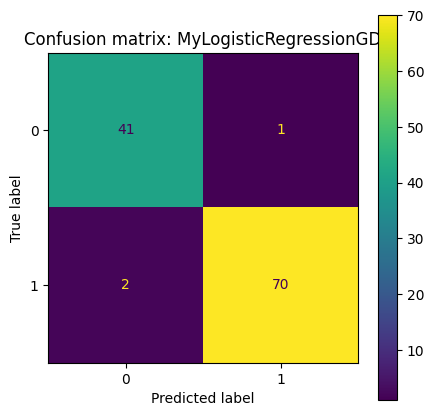

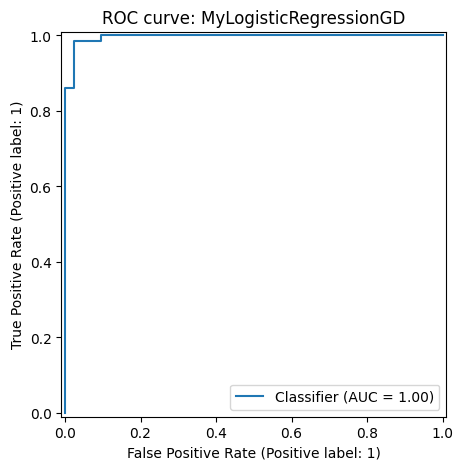

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [88]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, l2_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, l2_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, l2_pred_test))

## Задание B

In [92]:
# топ 10 признаков которые дают основной вклад по модулю в модель
top10_features = (
    pd.DataFrame({
        "feature": X.columns,
        "coef": my_model.w,
        "abs_coef": np.abs(my_model.w),
        "direction": np.where(my_model.w > 0, "toward benign", "toward malignant")
    })
    .sort_values("abs_coef", ascending=False)
    .head(10)
    .reset_index(drop=True))

print(top10_features)

                feature      coef  abs_coef         direction
0         worst texture -0.733522  0.733522  toward malignant
1          worst radius -0.680629  0.680629  toward malignant
2            worst area -0.648136  0.648136  toward malignant
3  worst concave points -0.636987  0.636987  toward malignant
4       worst perimeter -0.633773  0.633773  toward malignant
5          mean texture -0.599529  0.599529  toward malignant
6          radius error -0.566444  0.566444  toward malignant
7           mean radius -0.538792  0.538792  toward malignant
8   mean concave points -0.538530  0.538530  toward malignant
9             mean area -0.537316  0.537316  toward malignant


по таблице видно, что самые большие веса модель дала признаком с размером и неровностью опухоли, + видно что модель дает отрицательный вес, что логично тк как нулевой класс эт злокачественная опухоль от сюда и вылезает минус

## Задание C

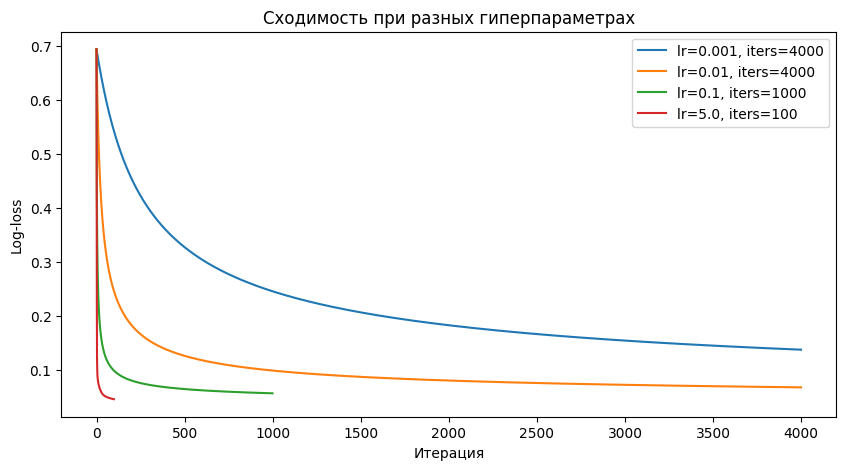

In [106]:
results = []
models = []

configs = [
    {"learning_rate": 0.001,"n_iters":4000},
    {"learning_rate": 0.01,"n_iters":4000},
    {"learning_rate": 0.1,"n_iters":1000},
    {"learning_rate": 5.0,"n_iters":100},
]

for cfg in configs :
    model = MyLogisticRegressionGD(
        learning_rate=cfg["learning_rate"],
        n_iters=cfg["n_iters"],
        threshold=0.5
    )
    
    model.fit(X_train_scaled,y_train)
    pred_test = model.predict(X_test_scaled)
    proba_test = model.predict_proba(X_test_scaled)
    
    results.append({
        "learning_rate" : cfg["learning_rate"],
        "n_iters": cfg["n_iters"],
        "accuracy" : accuracy_score(y_test,pred_test),
        "precision" : precision_score(y_test,pred_test),
        "recall": recall_score(y_test,pred_test),
        "f1": f1_score(y_test,pred_test),
        "roc-auc": roc_auc_score(y_test, proba_test),
        "final_loss" : model.loss_history[-1]
        }
    )
    
    models.append(model)
    
plt.figure(figsize=(10, 5))

for model, cfg in zip(models, configs):
    plt.plot(
        model.loss_history,
        label=f"lr={cfg['learning_rate']}, iters={cfg['n_iters']}"
    )

plt.title("Сходимость при разных гиперпараметрах")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.legend()
plt.show()

По графику видно, что при увелечении learning_rate увеличивается скорость сходимости, на текущем датасте большой рейт показывает хорошее поведение, но желательно использовать меньший тк можно проскочить минимум.